# Task 2: Multi-Modal Cardiac Image Fusion

**Scenario:** Fuse co-registered CT and MRI slices of the same heart into a single unified matrix.  
CT excels at sharp anatomical boundaries; MRI excels at soft-tissue contrast.  
The goal is to preserve both signals in one diagnostic image.

**Pipeline overview:**
1. Load & preprocess CT + MRI slices
2. Histogram Equalization (independent, per-modality)
3. Color Mapping → false-color heatmaps
4. Multi-modal Weighted Fusion (`cv2.addWeighted`)
5. Logarithmic + Power-Law (Gamma) Transformations on fused output
6. Comparative side-by-side analysis

## 0. Imports & Configuration

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

CT_PATH  = '/content/ct_slice_001.png'
MRI_PATH = '/content/mri_slice_001.png'
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CT = heavier weight to preserve sharp anatomical edges.
# MRI = lighter weight to inject soft-tissue variation.
ALPHA = 0.65   # CT weight
BETA  = 0.35   # MRI weight  (ALPHA + BETA should = 1.0 for a clean blend)
GAMMA_SCALAR = 0  # scalar offset in cv2.addWeighted (keep 0 for pure blend)

LOG_C      = 1.0   # log transform: s = C * log(1 + r)
GAMMA_VAL  = 0.6   # power-law: s = r ^ gamma  (< 1 → brighten midtones)

print("Imports OK.  CT weight:", ALPHA, "| MRI weight:", BETA)

Imports OK.  CT weight: 0.65 | MRI weight: 0.35


## 1. Load Modalities

Both images must be the **same spatial resolution** (co-registered slices of the same heart).  
If sizes differ, the resize below makes them match — but note this is a geometric convenience, not a proper registration step.

CT  → shape: (256, 256),  dtype: uint8
MRI → shape: (256, 256), dtype: uint8


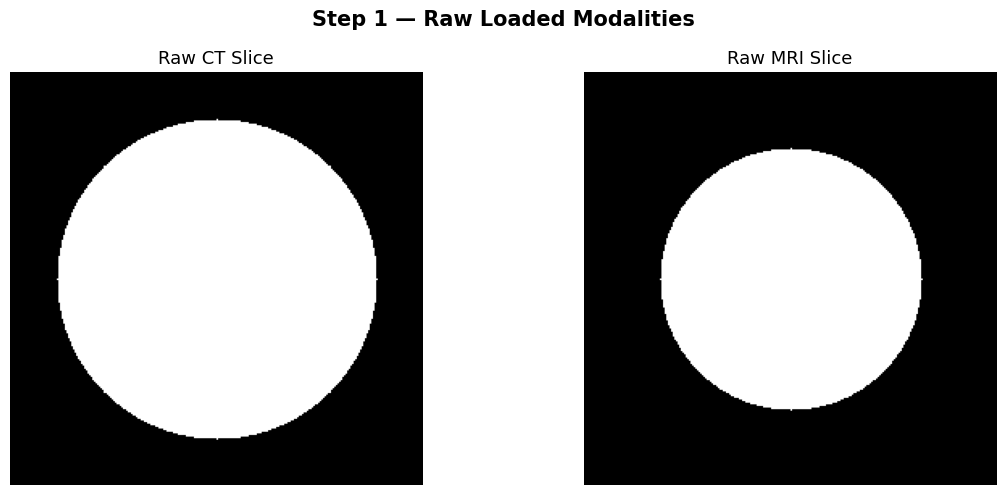

In [2]:
def load_grayscale(path: str) -> np.ndarray:
    """Load an image as uint8 grayscale.  Raises if file not found."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(
            f"Could not load: '{path}'.\n"
            "Place your CT slice at data/sample_ct.png and "
            "the paired MRI slice at data/sample_mri.png."
        )
    return img

ct_raw  = load_grayscale(CT_PATH)
mri_raw = load_grayscale(MRI_PATH)

if ct_raw.shape != mri_raw.shape:
    print(f"[WARNING] Shape mismatch → resizing MRI from "
          f"{mri_raw.shape} to {ct_raw.shape}.")
    mri_raw = cv2.resize(mri_raw, (ct_raw.shape[1], ct_raw.shape[0]),
                         interpolation=cv2.INTER_LINEAR)

H, W = ct_raw.shape
print(f"CT  → shape: {ct_raw.shape},  dtype: {ct_raw.dtype}")
print(f"MRI → shape: {mri_raw.shape}, dtype: {mri_raw.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(ct_raw,  cmap='gray'); axes[0].set_title('Raw CT Slice',  fontsize=13); axes[0].axis('off')
axes[1].imshow(mri_raw, cmap='gray'); axes[1].set_title('Raw MRI Slice', fontsize=13); axes[1].axis('off')
plt.suptitle('Step 1 — Raw Loaded Modalities', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_raw_modalities.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Histogram Equalization (per-modality, independent)

**Why equalize before blending?**  
CT and MRI scanners use entirely different intensity scales.  
If we blended raw pixel values, one modality would dominate purely because of scanner calibration, not actual tissue contrast.  
Equalizing each matrix independently remaps both to the full [0, 255] range, ensuring the weighted blend is a genuine information merge — not an accidental brightness competition.

`cv2.equalizeHist` works on uint8 single-channel images and produces a flat(ter) histogram — every intensity level represents roughly the same number of pixels.

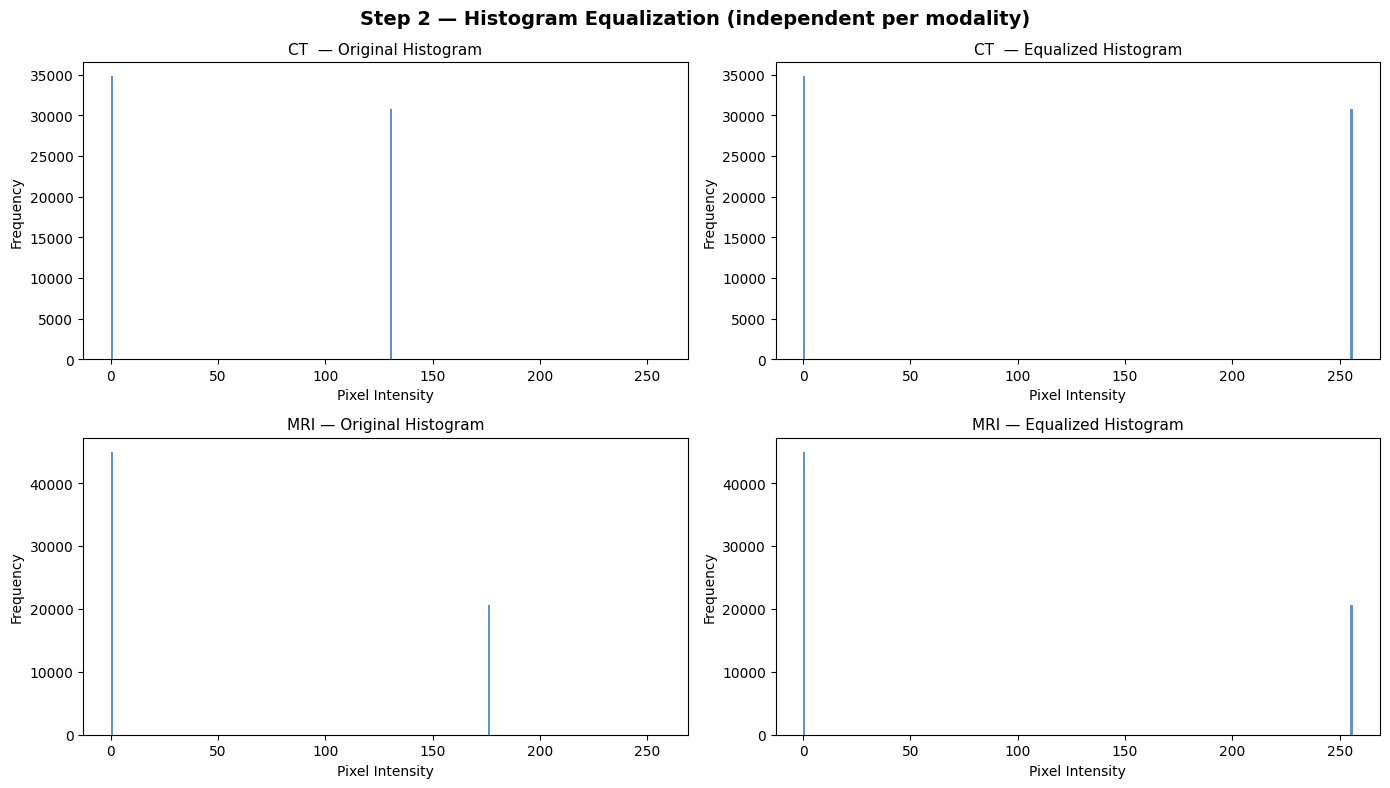

In [12]:
ct_eq  = cv2.equalizeHist(ct_raw)
mri_eq = cv2.equalizeHist(mri_raw)

#plot histograms before and after
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, img, label in [
    (axes[0,0], ct_raw,  'CT  — Original Histogram'),
    (axes[0,1], ct_eq,   'CT  — Equalized Histogram'),
    (axes[1,0], mri_raw, 'MRI — Original Histogram'),
    (axes[1,1], mri_eq,  'MRI — Equalized Histogram'),
]:
    ax.hist(img.ravel(), bins=256, range=[0, 256], color='steelblue', alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Pixel Intensity'); ax.set_ylabel('Frequency')

plt.suptitle('Step 2 — Histogram Equalization (independent per modality)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_histogram_equalization.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Color Mapping — False-Color Heatmaps

**CT → BONE colormap:** Preserves the grey-to-white feel of clinical CT, making bone vs. soft tissue immediately legible.  
**MRI → JET colormap:** Maps the intensity range to a blue→green→red spectrum, making subtle soft-tissue variations visible as distinct hues.  

After `applyColorMap`, both matrices are BGR uint8 with shape `(H, W, 3)`, ready for weighted blending.

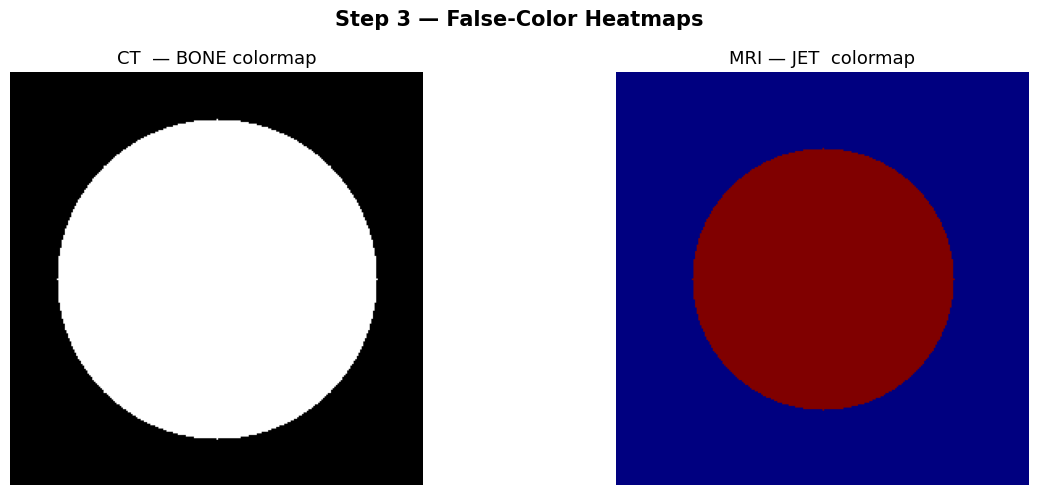

In [4]:
ct_color  = cv2.applyColorMap(ct_eq,  cv2.COLORMAP_BONE)   # steel-grey → bone
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)    # blue → green → red

ct_color_rgb  = cv2.cvtColor(ct_color,  cv2.COLOR_BGR2RGB)
mri_color_rgb = cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(ct_color_rgb);  axes[0].set_title('CT  — BONE colormap',  fontsize=13); axes[0].axis('off')
axes[1].imshow(mri_color_rgb); axes[1].set_title('MRI — JET  colormap', fontsize=13); axes[1].axis('off')
plt.suptitle('Step 3 — False-Color Heatmaps', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_color_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Multi-Modal Weighted Fusion

**Formula:**  
$$\text{fused}(x,y) = \alpha \cdot CT_{color}(x,y) + \beta \cdot MRI_{color}(x,y) + \gamma_{scalar}$$

Where:
- $\alpha = 0.65$ → CT dominates (preserves sharp anatomical borders)
- $\beta = 0.35$ → MRI contributes (injects soft-tissue variation)
- $\gamma_{scalar} = 0$ → no global brightness offset

**Why these weights?**  
The task explicitly asks for a *heavier CT weight* to keep structural edges legible.  
A 65/35 split is a reasonable starting ratio — in a clinical context these would be tuned empirically per patient and anatomy region.

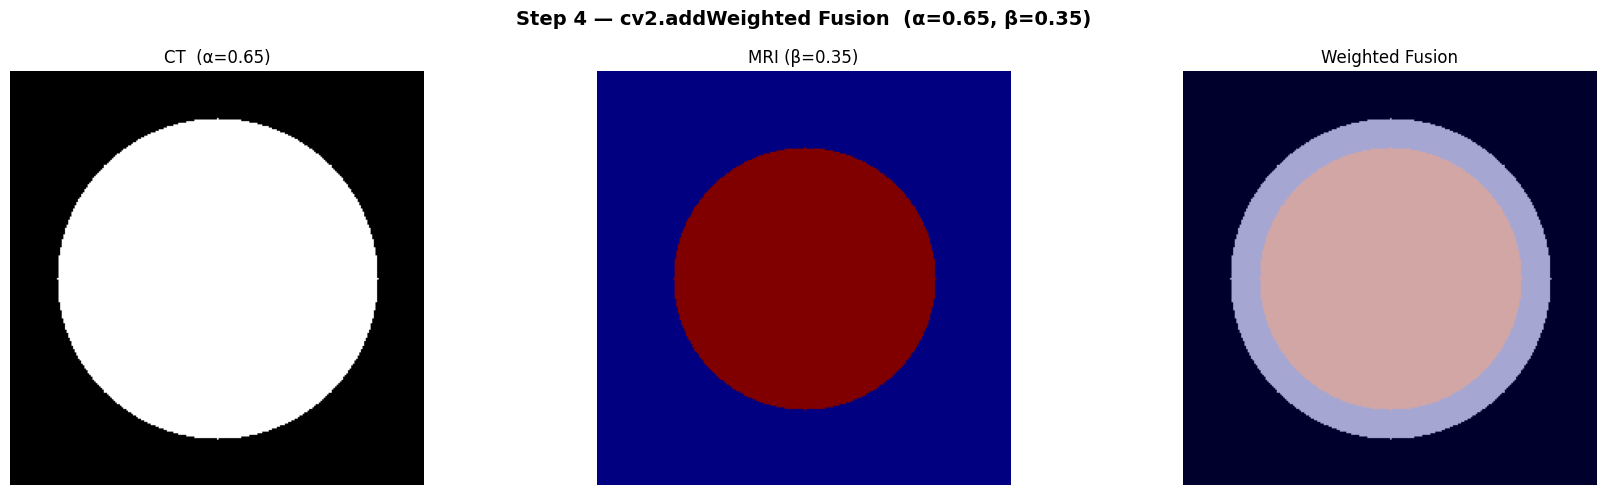

Fused image → shape: (256, 256, 3), dtype: uint8
  min pixel: 0   max pixel: 211


In [5]:
fused_bgr = cv2.addWeighted(ct_color, ALPHA, mri_color, BETA, GAMMA_SCALAR)
fused_rgb = cv2.cvtColor(fused_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(ct_color_rgb);  axes[0].set_title(f'CT  (α={ALPHA})',     fontsize=12); axes[0].axis('off')
axes[1].imshow(mri_color_rgb); axes[1].set_title(f'MRI (β={BETA})',      fontsize=12); axes[1].axis('off')
axes[2].imshow(fused_rgb);     axes[2].set_title('Weighted Fusion',       fontsize=12); axes[2].axis('off')
plt.suptitle(f'Step 4 — cv2.addWeighted Fusion  (α={ALPHA}, β={BETA})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_weighted_fusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fused image → shape: {fused_bgr.shape}, dtype: {fused_bgr.dtype}")
print(f"  min pixel: {fused_bgr.min()}   max pixel: {fused_bgr.max()}")

## 5. Logarithmic Transformation on Fused Matrix

**Formula:** $s = C \cdot \log(1 + r)$  where $r \in [0, 255]$ (normalized to $[0,1]$ then back)

**Purpose:**  
After the weighted addition, dark cardiac chambers (blood-filled cavities) may still be crushed near 0.  
The log curve compresses the bright range and *expands the dark range*, revealing low-intensity detail.  
The $+1$ inside the log prevents $\log(0)$ blow-up at zero-intensity pixels.

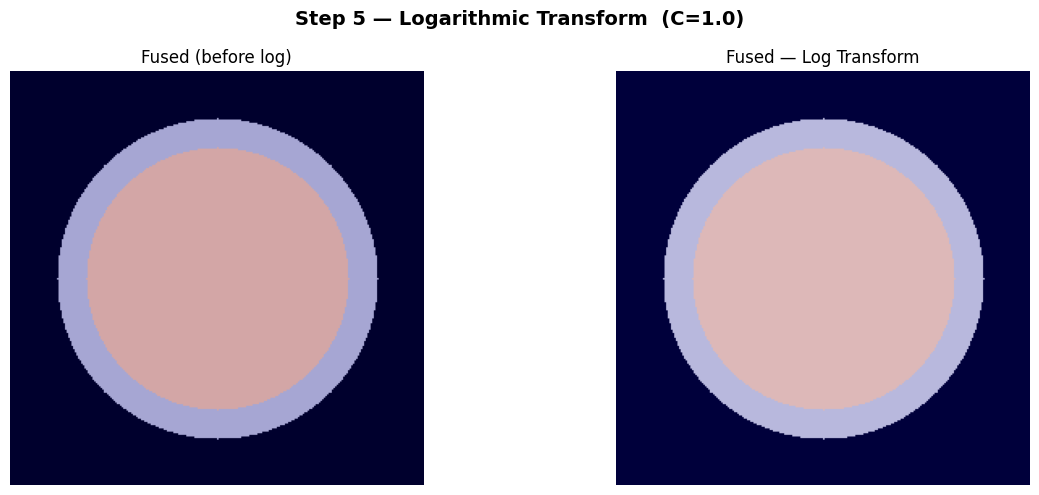

In [6]:
def log_transform(img_bgr: np.ndarray, c: float = 1.0) -> np.ndarray:

    img_float = img_bgr.astype(np.float64) / 255.0        # [0, 1]
    log_out   = c * np.log1p(img_float)                   # np.log1p = log(1+x)
    # Rescale the output back to [0, 255] using the theoretical max of log(1+1)=log(2)
    log_out   = log_out / np.log(2)                       # normalise by max possible value
    log_out   = np.clip(log_out * 255, 0, 255).astype(np.uint8)
    return log_out

fused_log     = log_transform(fused_bgr, c=LOG_C)
fused_log_rgb = cv2.cvtColor(fused_log, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(fused_rgb);     axes[0].set_title('Fused (before log)',    fontsize=12); axes[0].axis('off')
axes[1].imshow(fused_log_rgb); axes[1].set_title('Fused — Log Transform', fontsize=12); axes[1].axis('off')
plt.suptitle(f'Step 5 — Logarithmic Transform  (C={LOG_C})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Power-Law (Gamma) Transformation on Fused Matrix

**Formula:** $s = r^{\gamma}$   where $r \in [0, 1]$

**Purpose:**  
With $\gamma < 1$ (here $\gamma = 0.6$), midtones are brightened while pure blacks and whites stay anchored.  
This prevents the bright cardiac wall boundaries from being blown out to pure white during blending,  
while simultaneously lifting the darker myocardium and chamber walls into a visible grey range.

We apply gamma *to the log-transformed output* for a double-pass tone correction.

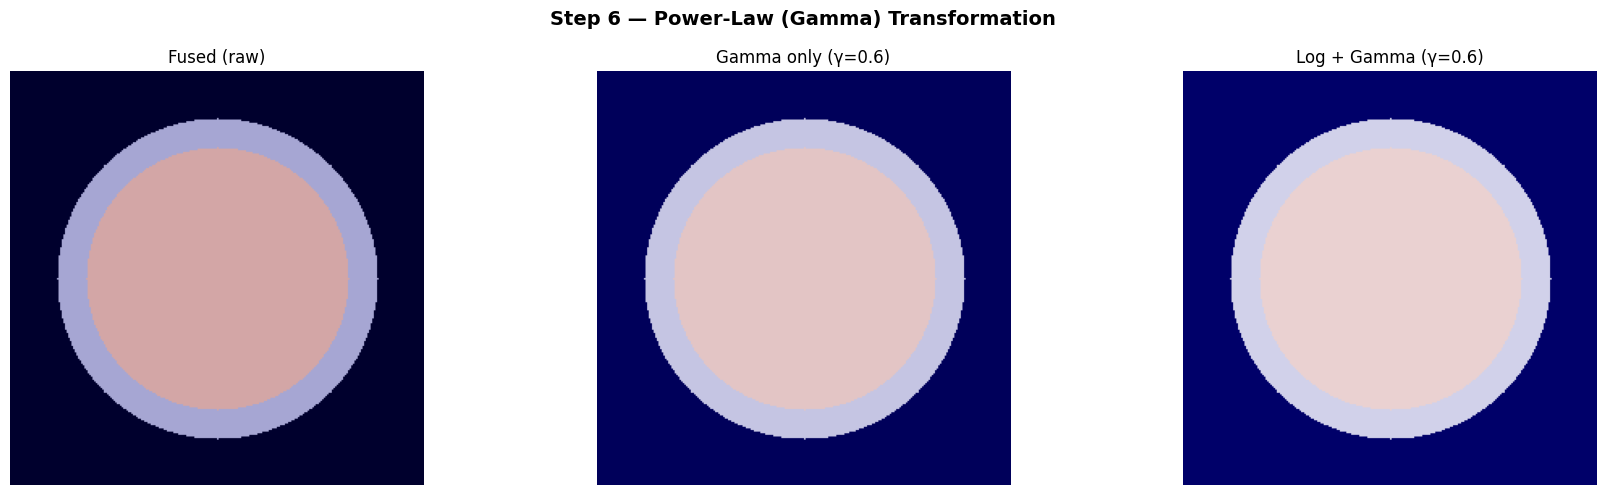

In [7]:
def gamma_transform(img_bgr: np.ndarray, gamma: float = 0.6) -> np.ndarray:

    # Build a 256-entry LUT: for each input intensity i, compute output
    lut = np.array([
        np.clip((i / 255.0) ** gamma * 255, 0, 255)
        for i in range(256)
    ], dtype=np.uint8)
    return cv2.LUT(img_bgr, lut)   # applies LUT per channel simultaneously

# Apply gamma on top of log-transformed fused image
fused_gamma     = gamma_transform(fused_log, gamma=GAMMA_VAL)
fused_gamma_rgb = cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB)

# Also apply gamma directly to raw fused (to show individual effect)
fused_gamma_direct     = gamma_transform(fused_bgr, gamma=GAMMA_VAL)
fused_gamma_direct_rgb = cv2.cvtColor(fused_gamma_direct, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(fused_rgb);             axes[0].set_title('Fused (raw)',               fontsize=12); axes[0].axis('off')
axes[1].imshow(fused_gamma_direct_rgb);axes[1].set_title(f'Gamma only (γ={GAMMA_VAL})',fontsize=12); axes[1].axis('off')
axes[2].imshow(fused_gamma_rgb);       axes[2].set_title(f'Log + Gamma (γ={GAMMA_VAL})',fontsize=12); axes[2].axis('off')
plt.suptitle('Step 6 — Power-Law (Gamma) Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_gamma_transform.png', dpi=150, bbox_inches='tight')
plt.show()

# The double-pass output is our final enhanced fused image
final_fused     = fused_gamma
final_fused_rgb = fused_gamma_rgb

## 7. Comparative Analysis — Full Pipeline



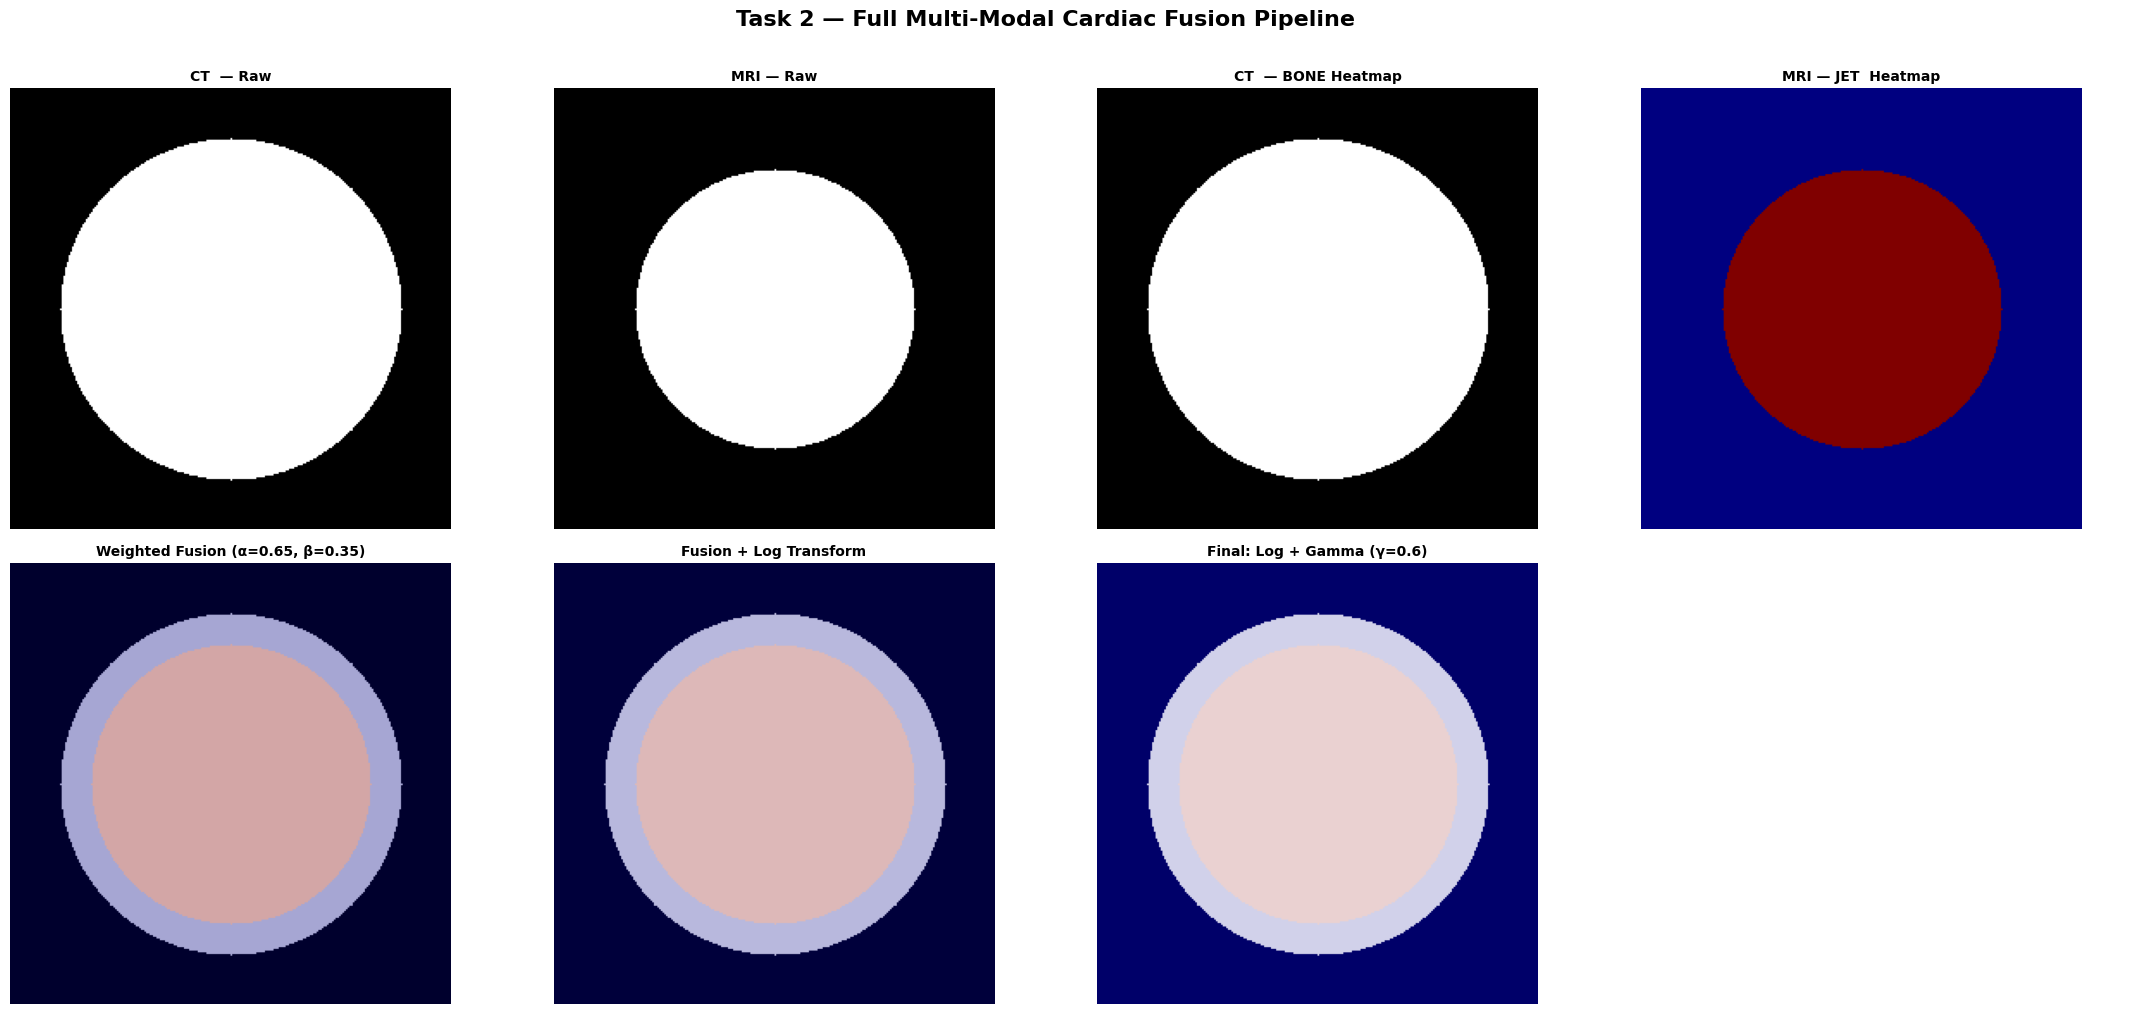

Full comparison saved to output/07_full_pipeline_comparison.png


In [8]:
panels = [
    (ct_raw,         'gray', 'CT  — Raw'),
    (mri_raw,        'gray', 'MRI — Raw'),
    (ct_color_rgb,   None,   'CT  — BONE Heatmap'),
    (mri_color_rgb,  None,   'MRI — JET  Heatmap'),
    (fused_rgb,      None,   'Weighted Fusion (α=0.65, β=0.35)'),
    (fused_log_rgb,  None,   'Fusion + Log Transform'),
    (final_fused_rgb,None,   f'Final: Log + Gamma (γ={GAMMA_VAL})'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for idx, (img, cmap, title) in enumerate(panels):
    r, c = divmod(idx, 4)
    axes[r, c].imshow(img, cmap=cmap)
    axes[r, c].set_title(title, fontsize=10, fontweight='bold')
    axes[r, c].axis('off')


axes[1, 3].axis('off')

plt.suptitle('Task 2 — Full Multi-Modal Cardiac Fusion Pipeline', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_full_pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Full comparison saved to output/07_full_pipeline_comparison.png")

In [10]:
cv2.imwrite(f'{OUTPUT_DIR}/ct_bone_heatmap.png',    ct_color)
cv2.imwrite(f'{OUTPUT_DIR}/mri_jet_heatmap.png',    mri_color)
cv2.imwrite(f'{OUTPUT_DIR}/fused_weighted.png',     fused_bgr)
cv2.imwrite(f'{OUTPUT_DIR}/fused_log.png',          fused_log)
cv2.imwrite(f'{OUTPUT_DIR}/fused_final.png',        final_fused)

print("All outputs saved to output/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

All outputs saved to output/:
  01_raw_modalities.png
  02_equalized_images.png
  02_histogram_equalization.png
  03_color_heatmaps.png
  04_weighted_fusion.png
  05_log_transform.png
  06_gamma_transform.png
  07_full_pipeline_comparison.png
  08_quantitative_stats.png
  ct_bone_heatmap.png
  fused_final.png
  fused_log.png
  fused_weighted.png
  mri_jet_heatmap.png


---
## Summary

| Stage | Operation | Mathematical Intent |
|---|---|---|
| 1 | Load + align | Ensure spatial correspondence |
| 2 | `cv2.equalizeHist` (CT, MRI independently) | Remove scanner-calibration bias; expand dynamic range |
| 3 | `applyColorMap(BONE / JET)` | Map intensity → colour for human perceptual advantage |
| 4 | `addWeighted(CT×0.65 + MRI×0.35)` | Preserve anatomical sharpness; inject soft-tissue variation |
| 5 | Log transform `s = log(1+r)` | Expand crushed dark regions (blood chambers) |
| 6 | Gamma transform `s = r^0.6` | Lift midtones; protect highlights from blow-out |
| 7 | Visual + quantitative comparison | Validate fusion success |
